#Introduction

##Fake News Detection using NLP

Fake news detection is an important Natural Language Processing (NLP) problem.
The goal of this project is to classify news articles as real or fake using
machine learning techniques.

In this project we use:

• TF-IDF for text feature extraction

• Logistic Regression for classification

Dataset: Fake and Real News Dataset

#Dataset Description

## Dataset Description

The dataset contains two files:

Fake.csv → Fake news articles  
True.csv → Real news articles  

Columns:
• title – Title of the news article
• text – Full article content
• subject – News category
• date – Publication date

Total articles ≈ 44,000

#Data Preprocessing

In [45]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
fake = pd.read_csv("Fake.csv", engine="python")
true = pd.read_csv("True.csv", engine="python")

# Add labels
fake["label"] = 0
true["label"] = 1

# Combine datasets
df = pd.concat([fake, true])

# Shuffle dataset
df = df.sample(frac=1)

# Display dataset
df.head()

,title,text,subject,date,label
14573,"German coalition impasse can be resolved, Merk...",BERLIN (Reuters) - The chief of staff to Germa...,worldnews,"November 17, 2017",1
22171,The Corporate Plantation: NCAA College Sports ...,James Hall 21st Century WireThe obsession over...,US_News,"March 15, 2017",0
22418,Ammon and Ryan Bundy Found ‘Not Guilty’ in Ore...,"21st Century Wire Yesterday, Judge Anna Brown ...",US_News,"October 29, 2016",0
15698,Ousted Catalan leader calls for united front f...,MADRID/BARCELONA (Reuters) - Ousted Catalan le...,worldnews,"November 4, 2017",1
7769,U.S. civil rights groups to fan out on Nov. 8 ...,WASHINGTON (Reuters) - Donald Trump supporters...,politicsNews,"October 18, 2016",1


In [46]:
df.shape

(44898, 5)

In [47]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


#Exploratory Data Analysis

##Fake vs Real Distribution

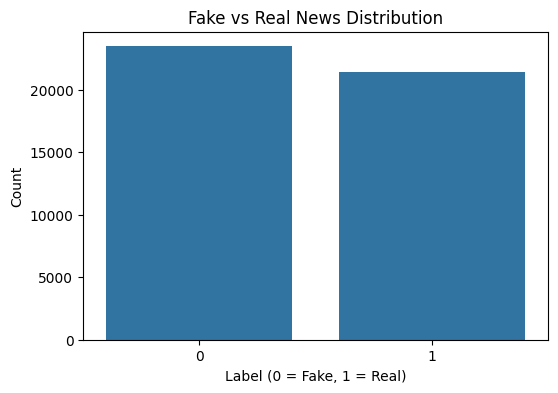

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Count")

plt.show()

##Article Length Analysis

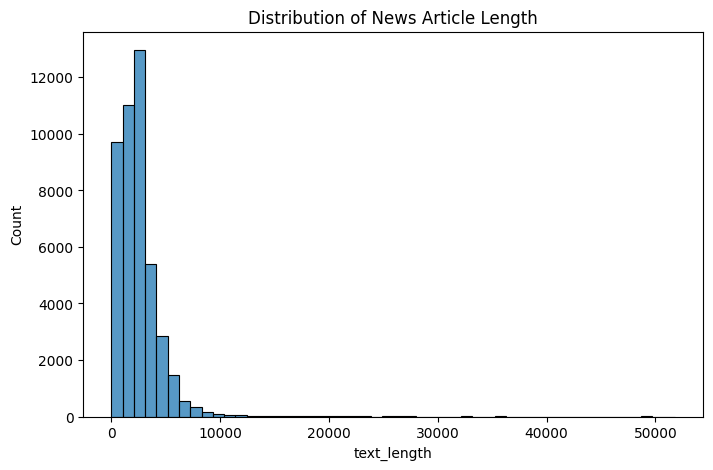

In [49]:
df["text_length"] = df["text"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=50)

plt.title("Distribution of News Article Length")

plt.show()

#Feature Engineering (TF-IDF)

Split dataset

In [50]:
from sklearn.model_selection import train_test_split

x = df["text"]
y = df["label"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

Convert text → numbers using TF-IDF

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

#Model Training

In [52]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train_vec, y_train)

LogisticRegression()

#Model Evaluation

Prediction

In [53]:
pred = model.predict(x_test_vec)

Accuracy

In [55]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy*100)

Accuracy: 98.49443207126949


Confusion Matrix

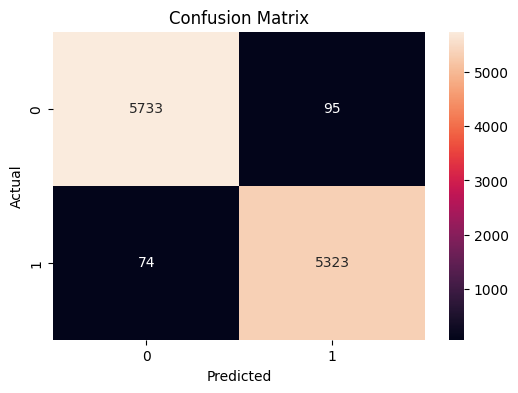

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5828
           1       0.98      0.99      0.98      5397

    accuracy                           0.98     11225
   macro avg       0.98      0.98      0.98     11225
weighted avg       0.98      0.98      0.98     11225



#Prediction System

In [58]:
def predict_news(news_text):

    news_vec = vectorizer.transform([news_text])

    prediction = model.predict(news_vec)

    if prediction[0] == 1:
        return "Real News"
    else:
        return "Fake News"

Test the system

In [60]:
news = "Government announces new economic reforms for education sector"

print(predict_news(news))

Real News


#Conclusion



In this project we built a Fake News Detection system using NLP.

Steps performed:

• Data preprocessing

• Exploratory data analysis

• Feature extraction using TF-IDF

• Model training using Logistic Regression

• Model evaluation

The model achieved about 98% accuracy in detecting fake and real news.

This project demonstrates how machine learning can be applied to solve real-world misinformation problems.